Predict the rent of the house from a given dataset. Perform following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the correlation.
4. Implement linear model.
5.Evaluate the models and compare their respective scores like R2, RMSE, etc.

Use : https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [19]:
data = pd.read_csv("D:/KAUSTUBH/LP3 Final/House_Rent_Dataset.csv")

print(data.head())

    Posted On  BHK   Rent  Size            Floor    Area Type  \
0  2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1  2022-05-13    2  20000   800       1 out of 3   Super Area   
2  2022-05-16    2  17000  1000       1 out of 3   Super Area   
3  2022-07-04    2  10000   800       1 out of 2   Super Area   
4  2022-05-09    2   7500   850       1 out of 2  Carpet Area   

              Area Locality     City Furnishing Status  Tenant Preferred  \
0                    Bandel  Kolkata       Unfurnished  Bachelors/Family   
1  Phool Bagan, Kankurgachi  Kolkata    Semi-Furnished  Bachelors/Family   
2   Salt Lake City Sector 2  Kolkata    Semi-Furnished  Bachelors/Family   
3               Dumdum Park  Kolkata       Unfurnished  Bachelors/Family   
4             South Dum Dum  Kolkata       Unfurnished         Bachelors   

   Bathroom Point of Contact  
0         2    Contact Owner  
1         1    Contact Owner  
2         1    Contact Owner  
3         1    Contact Owner

In [20]:
# Extract numerical values from the 'Floor' column
data['Floor Level'] = data['Floor'].str.extract(r'(\d+)').fillna(0).astype(int)

In [21]:
data = data.drop(['Posted On', 'Point of Contact','Floor', 'Area Locality'], axis=1)

In [22]:
# One-hot encode categorical columns (e.g., 'Area Type', 'City', 'Furnishing Status')
data = pd.get_dummies(data, columns=['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred'], drop_first=True)

In [23]:
# Identify outliers based on 'Rent' (99th percentile)
data = data[data['Rent'] < data['Rent'].quantile(0.99)]

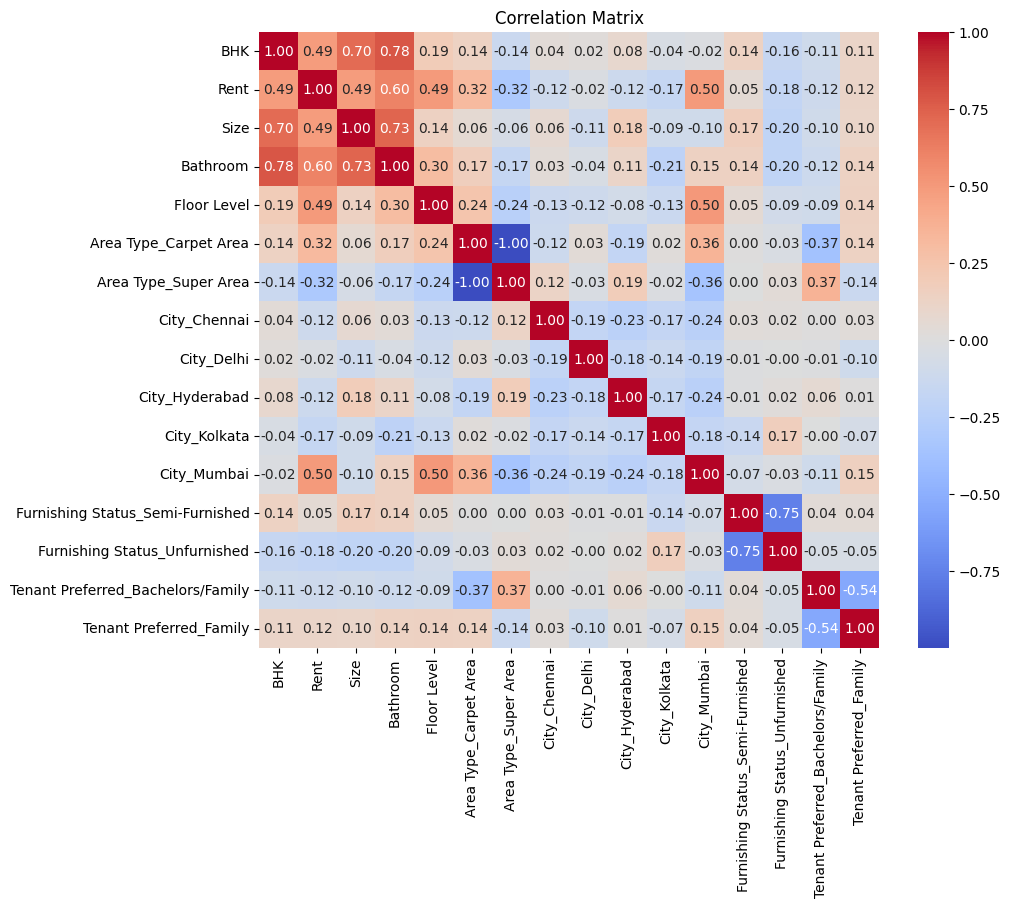

In [24]:
# Check correlation
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [25]:
# Prepare data for training
X = data.drop(['Rent'], axis=1)
y = data['Rent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
# Evaluate model
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.6593245415708426
RMSE: 22942.337960853245
MAE: 14322.210200018913


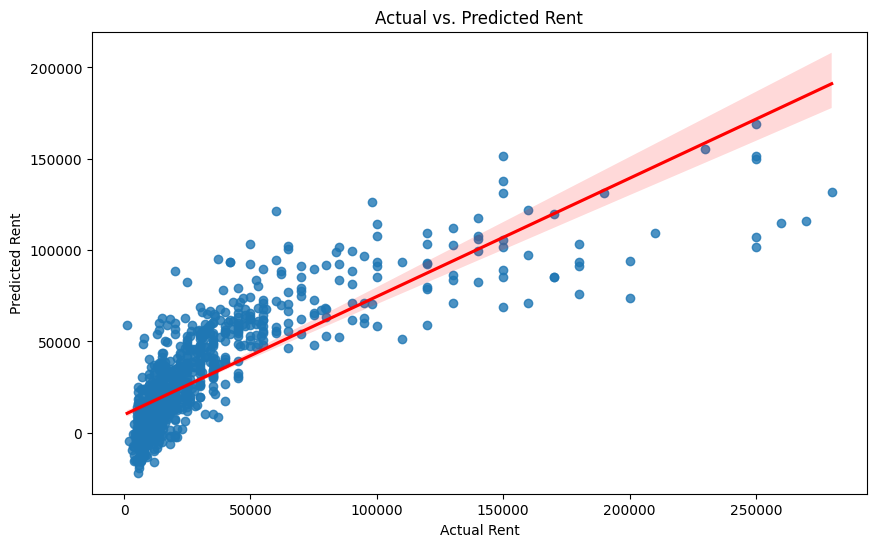

In [28]:
# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, line_kws={'color': 'red'})
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs. Predicted Rent")
plt.show()